<a href="https://colab.research.google.com/github/Sangeetha231005/MLOps_Training/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercise: Handwritten Digit Classification using CNN on MNIST Dataset**

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print(X_train.shape)
print(X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


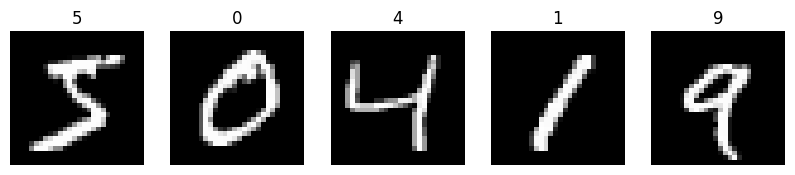

In [3]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)

(60000, 28, 28, 1)


In [6]:
cnn = models.Sequential([

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
cnn.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 28ms/step - accuracy: 0.9555 - loss: 0.1448
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9851 - loss: 0.0486
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9896 - loss: 0.0344
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9918 - loss: 0.0251
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9938 - loss: 0.0190


In [9]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9903 - loss: 0.0293


[0.029322106391191483, 0.9902999997138977]

In [10]:
y_pred = cnn.predict(X_test)

y_classes = [np.argmax(i) for i in y_pred]

print(y_classes[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9)]
[7 2 1 0 4 1 4 9 5 9]


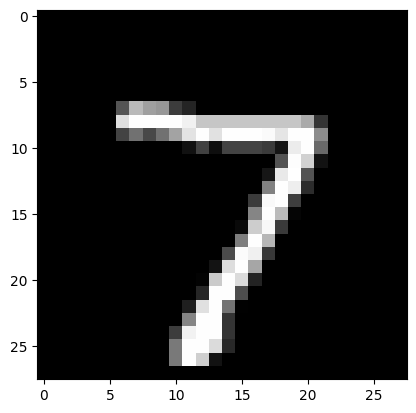

Predicted Digit = 7
Actual Digit = 7


In [11]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.show()

print("Predicted Digit =", y_classes[0])
print("Actual Digit =", y_test[0])

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.97      1.00      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

